# Day 4: Gates, Measurement, and Entanglement

**Clemson Quantum Club** · SC Quantathon v3 Bootcamp · [clemsonquantum.com](https://clemsonquantum.com)

In this notebook:
1. Setup
2. The Pauli gates as half-turns of the Bloch sphere
3. Rotations and the general single-qubit gate
4. Composing gates: order matters
5. Measurement: collapse, shots, and the choice of basis
6. Expectation values and the Estimator
7. Two qubits: tensor products and Qiskit's bit ordering
8. Product states and entangled states
9. Two-qubit gates: CNOT, CZ, SWAP, and controlled versions of anything
10. The Bell state
11. Correlations in more than one basis
12. GHZ states and the cost of simulating $n$ qubits
13. The Bell state on a real processor (optional)

> Cells marked **Your turn** have a few lines for you to fill in. Cells marked **Checkpoint** contain `assert` statements: if the cell runs without an error, the answer above it is correct. This is the solutions notebook: every Your turn cell is filled in and hardware runs are switched on.

## 1. Setup

Same two paths as before: the `scqv3` conda environment, or qBraid Lab. Everything today runs on a simulator. The cell defines the matrices and the `bloch_vector` function from Day 2, which this notebook uses throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, Pauli, SparsePauliOp, partial_trace
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.visualization import plot_histogram, plot_bloch_multivector

np.set_printoptions(precision=3, suppress=True)

SHOTS = 1000

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

def bloch_vector(state):
    return np.array([state.expectation_value(Pauli(a)).real for a in "XYZ"])

def bloch_state(theta, phi):
    return Statevector([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)])

sampler = StatevectorSampler(seed=np.random.default_rng(7))
estimator = StatevectorEstimator()

def counts_of(qc, shots=SHOTS):
    return sampler.run([qc], shots=shots).result()[0].data.meas.get_counts()

def expectation(qc, label):
    return float(estimator.run([(qc, SparsePauliOp(label))]).result()[0].data.evs)

def gate_matrix(build):
    qc = QuantumCircuit(1)
    build(qc)
    return Operator(qc).data

RUN_ON_HARDWARE = True      # section 13 only; leave False to use a cached result

# Load the IBM account saved on Day 1, if there is one. Nothing here needs it until section 13.
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(name="scqv3")
    print("IBM account 'scqv3' loaded.")
except Exception as e:
    service = None
    print("No saved IBM account:", type(e).__name__, "(fine until section 13)")

IBM account 'scqv3' loaded.


## 2. The Pauli gates as half-turns

Day 2 introduced $X$ and $Z$ as matrices. Together with $Y$ they are the **Pauli gates**:

$$X = \begin{pmatrix}0&1\\1&0\end{pmatrix},\qquad Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix},\qquad Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$

Each squares to the identity, so each is its own inverse, and any two of them anticommute: $XZ = -ZX$. On the Bloch sphere every one of them is a half-turn about its own axis. $X$ keeps the $x$ coordinate and flips $y$ and $z$; $Y$ keeps $y$; $Z$ keeps $z$.

In [2]:
for name, U in [("X", X), ("Y", Y), ("Z", Z)]:
    print(f"{name}|0> = {U @ ket0}    {name}|+> = {U @ (H @ ket0)}")

# Checkpoint: each Pauli squares to I, and any two anticommute
for name, U in [("X", X), ("Y", Y), ("Z", Z)]:
    assert np.allclose(U @ U, I2), f"{name}^2 should be I"
assert np.allclose(X @ Z, -Z @ X) and np.allclose(X @ Y, -Y @ X) and np.allclose(Y @ Z, -Z @ Y)
assert np.allclose(X @ Y, 1j * Z), "XY = iZ"
print("X^2 = Y^2 = Z^2 = I, and the three anticommute")

X|0> = [0.+0.j 1.+0.j]    X|+> = [0.707+0.j 0.707+0.j]
Y|0> = [0.+0.j 0.+1.j]    Y|+> = [0.-0.707j 0.+0.707j]
Z|0> = [1.+0.j 0.+0.j]    Z|+> = [ 0.707+0.j -0.707+0.j]
X^2 = Y^2 = Z^2 = I, and the three anticommute


Watch the half-turn happen. Start from a general point $(\theta,\phi)$ and apply each Pauli.

Before:       [0.612 0.612 0.5  ]
After X:      [ 0.612 -0.612 -0.5  ]
After Y:      [-0.612  0.612 -0.5  ]
After Z:      [-0.612 -0.612  0.5  ]


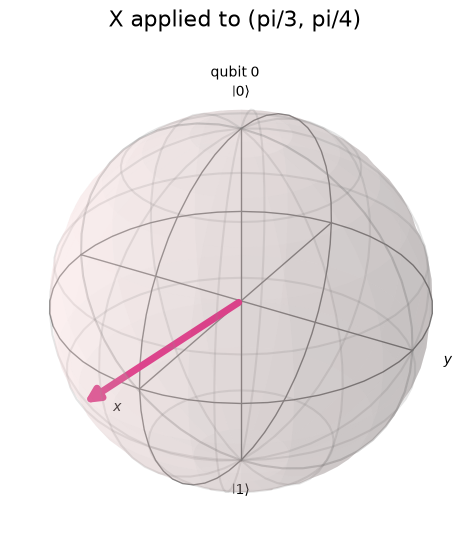

In [3]:
psi = bloch_state(np.pi / 3, np.pi / 4)
print("Before:      ", bloch_vector(psi))
for name, U in [("X", X), ("Y", Y), ("Z", Z)]:
    print(f"After {name}:     ", bloch_vector(psi.evolve(Operator(U))))

plot_bloch_multivector(psi.evolve(Operator(X)), title="X applied to (pi/3, pi/4)")

### Your turn: which coordinates survive

Fill in `expected_after`, a dictionary mapping each gate name to the Bloch vector you expect after applying it to `psi`, using only `before = bloch_vector(psi)` and sign flips.

In [4]:
before = bloch_vector(psi)
x, y, z = before
expected_after = {}

### WRITE YOUR CODE BELOW HERE ###
expected_after = {"X": [x, -y, -z], "Y": [-x, y, -z], "Z": [-x, -y, z]}

### YOUR CODE FINISHES HERE ###

In [5]:
# Checkpoint
assert set(expected_after) == {"X", "Y", "Z"}, "expected_after needs keys X, Y, Z: fill in the cell above"
for name, U in [("X", X), ("Y", Y), ("Z", Z)]:
    actual = bloch_vector(psi.evolve(Operator(U)))
    assert np.allclose(expected_after[name], actual, atol=1e-9), f"{name}: expected {expected_after[name]}, got {actual}"
print("Each Pauli keeps its own axis and flips the other two")

Each Pauli keeps its own axis and flips the other two


## 3. Rotations and the general single-qubit gate

The Pauli gates are half-turns. The **rotation gates** turn by any angle about the same three axes:

$$R_x(\theta) = \begin{pmatrix}\cos\frac\theta2 & -i\sin\frac\theta2\\ -i\sin\frac\theta2 & \cos\frac\theta2\end{pmatrix},\quad
R_y(\theta) = \begin{pmatrix}\cos\frac\theta2 & -\sin\frac\theta2\\ \sin\frac\theta2 & \cos\frac\theta2\end{pmatrix},\quad
R_z(\theta) = \begin{pmatrix}e^{-i\theta/2} & 0\\ 0 & e^{i\theta/2}\end{pmatrix}.$$

All three are $\exp(-i\theta A/2)$ for $A = X, Y, Z$. The half angle is the same half angle as in the Bloch sphere formula: $R_y(\theta)|0\rangle = \cos\frac\theta2|0\rangle + \sin\frac\theta2|1\rangle$ is the state at polar angle $\theta$, so $P(1) = \sin^2\frac\theta2$.

Every single-qubit gate is a rotation about some axis, and Qiskit's most general one-qubit gate writes it with three angles:

$$U(\theta,\phi,\lambda) = \begin{pmatrix}\cos\frac\theta2 & -e^{i\lambda}\sin\frac\theta2\\ e^{i\phi}\sin\frac\theta2 & e^{i(\phi+\lambda)}\cos\frac\theta2\end{pmatrix}.$$

Two named rotations about $z$ come up constantly: the **phase gate** $P(\lambda) = \mathrm{diag}(1, e^{i\lambda})$, with $S = P(\pi/2)$ and $T = P(\pi/4)$, so that $Z = S^2$ and $S = T^2$. $P(\lambda)$ differs from $R_z(\lambda)$ only by a global phase and leaves $P(0)$ and $P(1)$ unchanged.

In [6]:
def rx(t): return np.array([[np.cos(t/2), -1j*np.sin(t/2)], [-1j*np.sin(t/2), np.cos(t/2)]])
def ry(t): return np.array([[np.cos(t/2), -np.sin(t/2)], [np.sin(t/2), np.cos(t/2)]], dtype=complex)
def rz(t): return np.array([[np.exp(-1j*t/2), 0], [0, np.exp(1j*t/2)]])

t = 0.8
# Checkpoint: our matrices match Qiskit's gates
assert np.allclose(rx(t), gate_matrix(lambda qc: qc.rx(t, 0)))
assert np.allclose(ry(t), gate_matrix(lambda qc: qc.ry(t, 0)))
assert np.allclose(rz(t), gate_matrix(lambda qc: qc.rz(t, 0)))
# and a full turn is the identity up to a global phase of -1
assert np.allclose(ry(2 * np.pi), -I2)
print("R_x, R_y, R_z match Qiskit; R_y(2 pi) = -I (a full turn flips the global phase)")

R_x, R_y, R_z match Qiskit; R_y(2 pi) = -I (a full turn flips the global phase)


Sweep $\theta$ in $R_y$ and read $P(1)$ two ways: exactly from the state vector, and from `SHOTS` shots.

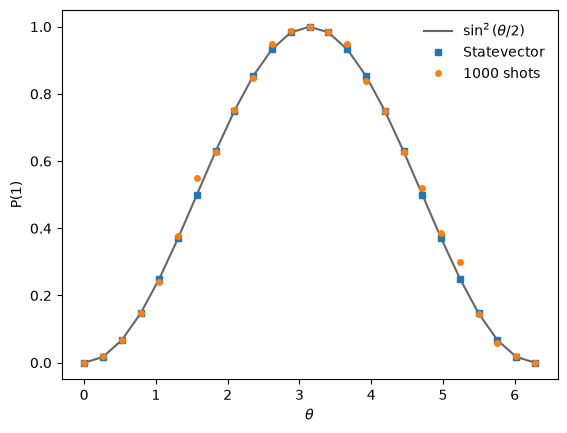

In [7]:
thetas = np.linspace(0, 2 * np.pi, 25)
p1_exact, p1_sampled = [], []
for th in thetas:
    qc = QuantumCircuit(1)
    qc.ry(th, 0)
    p1_exact.append(Statevector(qc).probabilities()[1])
    qc.measure_all()
    c = counts_of(qc)
    p1_sampled.append(c.get("1", 0) / SHOTS)

plt.plot(thetas, np.sin(thetas / 2) ** 2, "-", color="0.4", label=r"$\sin^2(\theta/2)$")
plt.plot(thetas, p1_exact, "s", ms=4, label="Statevector")
plt.plot(thetas, p1_sampled, "o", ms=4, label=f"{SHOTS} shots")
plt.xlabel(r"$\theta$"); plt.ylabel("P(1)"); plt.legend(frameon=False)
plt.show()

# Checkpoint
assert np.allclose(p1_exact, np.sin(thetas / 2) ** 2)
assert np.max(np.abs(np.array(p1_sampled) - p1_exact)) < 0.06, "sampled P(1) should track sin^2(theta/2) within a few sigma"

### Your turn: build $H$ out of rotations

$H$ is not one of the rotation gates, but it is a rotation. Build a one-qubit circuit `qc_h` that equals $H$ using only `ry`, `rz`, `z`, `x`, or `u`. Two of several answers: $H = R_y(\pi/2)\,Z$ as matrices (so in a circuit, $Z$ first, then $R_y(\pi/2)$), and $H = U(\pi/2, 0, \pi)$.

In [8]:
qc_h = QuantumCircuit(1)

### WRITE YOUR CODE BELOW HERE ###
qc_h.u(np.pi / 2, 0, np.pi, 0)

### YOUR CODE FINISHES HERE ###

In [9]:
# Checkpoint: same gate as H, up to a global phase
assert qc_h.size() > 0, "qc_h is empty: fill in the cell above"
assert "h" not in qc_h.count_ops(), "use rotations, not the h gate"
assert Operator(qc_h).equiv(Operator(H)), f"not H:\n{Operator(qc_h).data}"
print("qc_h equals H:", dict(qc_h.count_ops()))

qc_h equals H: {'u': 1}


## 4. Composing gates: order matters

A circuit is read left to right, but its matrix is the product of the gate matrices in the opposite order, because the first gate acts on the state first: a circuit with $A$ then $B$ has matrix $BA$. Gates do not commute in general, so $A$ then $B$ and $B$ then $A$ are usually different circuits.

In [10]:
qc_hzh = QuantumCircuit(1)
qc_hzh.h(0); qc_hzh.z(0); qc_hzh.h(0)

qc_xh = QuantumCircuit(1); qc_xh.x(0); qc_xh.h(0)     # X first, then H
qc_hx = QuantumCircuit(1); qc_hx.h(0); qc_hx.x(0)     # H first, then X

# Checkpoint: circuit H, Z, H has matrix H Z H = X; and X-then-H differs from H-then-X
assert np.allclose(Operator(qc_hzh).data, H @ Z @ H)
assert np.allclose(Operator(qc_hzh).data, X)
assert np.allclose(Operator(qc_xh).data, H @ X)      # written right to left
assert not np.allclose(Operator(qc_xh).data, Operator(qc_hx).data)
print("Matrix of (H, Z, H) is H Z H = X; (X then H) and (H then X) are different gates")

Matrix of (H, Z, H) is H Z H = X; (X then H) and (H then X) are different gates


Every circuit can be undone. `inverse()` reverses the gate order and replaces each gate by its adjoint, and composing a circuit with its inverse is the identity.

In [11]:
qc_any = QuantumCircuit(1)
qc_any.ry(0.7, 0); qc_any.t(0); qc_any.rx(-1.9, 0)

undo = qc_any.inverse()
roundtrip = qc_any.compose(undo)
print(roundtrip.draw())

# Checkpoint
assert Operator(roundtrip).equiv(Operator(I2))
assert np.allclose(Operator(undo).data, Operator(qc_any).data.conj().T)
print("Inverse() is the adjoint, and circuit + inverse is the identity")

   ┌─────────┐┌───┐┌──────────┐┌─────────┐┌─────┐┌──────────┐
q: ┤ Ry(0.7) ├┤ T ├┤ Rx(-1.9) ├┤ Rx(1.9) ├┤ Tdg ├┤ Ry(-0.7) ├
   └─────────┘└───┘└──────────┘└─────────┘└─────┘└──────────┘
Inverse() is the adjoint, and circuit + inverse is the identity


## 5. Measurement

### 5.1 The Born rule and collapse

Measuring $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ returns 0 with probability $|\alpha|^2$ and 1 with probability $|\beta|^2$, and afterwards the state *is* $|0\rangle$ or $|1\rangle$: the superposition is gone. On an ideal device, measuring again returns the same value every time; on hardware, readout error and decay between the two readings make them disagree at the percent level. `Statevector.measure()` returns both the outcome and the state left behind.

In [12]:
sv = bloch_state(2 * np.pi / 3, 0.0)
sv.seed(11)
print("State before:       ", sv.data, "   P(1) =", sv.probabilities()[1])

outcome, after = sv.measure()
print("Outcome:            ", outcome)
print("State after:        ", after.data)

again = [after.measure()[0] for _ in range(10)]
print("Ten more readings:  ", "".join(again))

# Checkpoint: after a measurement the state is a basis state and every reading agrees
assert after.equiv(Statevector.from_label(outcome))
assert set(again) == {outcome}

State before:        [0.5  +0.j 0.866+0.j]    P(1) = 0.7499999999999999
Outcome:             0
State after:         [1.+0.j 0.+0.j]
Ten more readings:   0000000000


### 5.2 Shots, and the Sampler

Repeating the whole circuit $N$ times gives counts that estimate the probabilities with the $\sqrt{Np(1-p)}$ spread from Day 1. Day 1 used `AerSimulator().run`. Qiskit's **primitives** are the interface that works the same way on a simulator and on hardware: a `Sampler` takes circuits with measurements and returns counts. The classical register created by `measure_all()` is named `meas`, which is why the result is read as `data.meas`.

{'1': 778, '0': 222}    P(1) estimate: 0.778   exact: 0.7499999999999999


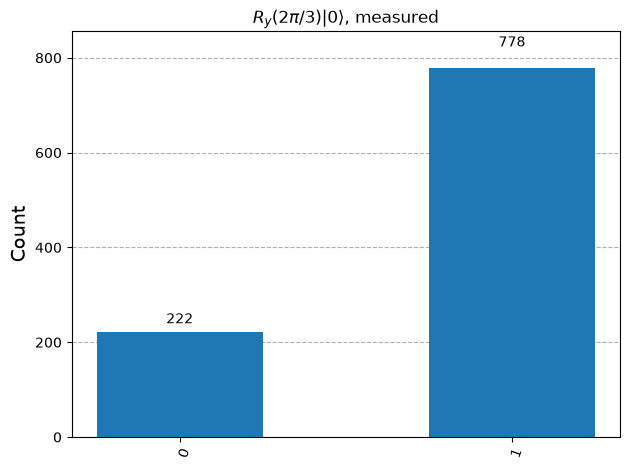

In [13]:
qc = QuantumCircuit(1)
qc.ry(2 * np.pi / 3, 0)
qc.measure_all()

result = sampler.run([qc], shots=SHOTS).result()
counts = result[0].data.meas.get_counts()
print(counts, "   P(1) estimate:", counts.get("1", 0) / SHOTS, "  exact:", np.sin(np.pi / 3) ** 2)

# Checkpoint
assert abs(counts.get("1", 0) / SHOTS - 0.75) < 0.05
plot_histogram(counts, title=r"$R_y(2\pi/3)|0\rangle$, measured")

### 5.3 Choosing the basis

A measurement always asks "0 or 1?" along the $z$ axis. To ask along another axis, rotate that axis onto $z$ first and then measure. $H$ swaps $x$ and $z$, so an $H$ before the measurement reads the qubit in the **$X$ basis** $\{|+\rangle, |-\rangle\}$, which Day 2 used to tell $|+\rangle$ from $|-\rangle$. For the **$Y$ basis** $\{|{+}i\rangle, |{-}i\rangle\}$ the rotation is $S^\dagger$ then $H$.

| basis | states | gates before measuring | outcome 0 means |
|---|---|---|---|
| $Z$ | $\lvert 0\rangle, \lvert 1\rangle$ | none | $\lvert 0\rangle$ |
| $X$ | $\lvert +\rangle, \lvert -\rangle$ | `h` | $\lvert +\rangle$ |
| $Y$ | $\lvert {+}i\rangle, \lvert {-}i\rangle$ | `sdg`, then `h` | $\lvert {+}i\rangle$ |

The state $|{+}i\rangle = H$ then $S$ applied to $|0\rangle$ sits on the $y$ axis. Measured in $Z$ or $X$ it is a fair coin; measured in $Y$ it is certain.

|+i> Bloch vector: [0. 1. 0.]
Z basis: {'1': 530, '0': 470}
X basis: {'1': 497, '0': 503}
Y basis: {'0': 1000}


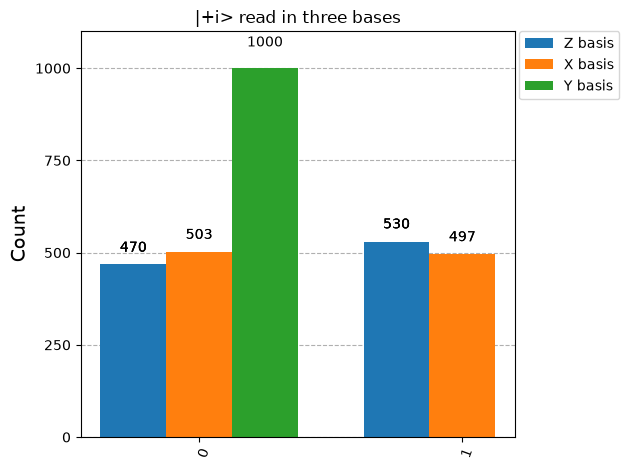

In [14]:
def measure_in_basis(prep, basis):
    qc = prep.copy()
    if basis == "X":
        qc.h(0)
    elif basis == "Y":
        qc.sdg(0); qc.h(0)
    qc.measure_all()
    return counts_of(qc)

prep_plus_i = QuantumCircuit(1)
prep_plus_i.h(0); prep_plus_i.s(0)
print("|+i> Bloch vector:", bloch_vector(Statevector(prep_plus_i)))

basis_counts = {b: measure_in_basis(prep_plus_i, b) for b in "ZXY"}
for b, c in basis_counts.items():
    print(f"{b} basis: {c}")

# Checkpoint: fair coin in Z and X, certain in Y
assert abs(basis_counts["Z"].get("0", 0) / SHOTS - 0.5) < 0.06
assert abs(basis_counts["X"].get("0", 0) / SHOTS - 0.5) < 0.06
assert basis_counts["Y"] == {"0": SHOTS}
plot_histogram(list(basis_counts.values()), legend=["Z basis", "X basis", "Y basis"], title="|+i> read in three bases")

### Your turn: predict, then measure

`prep_theta` prepares $R_y(2\pi/3)|0\rangle = \cos\frac\pi3|0\rangle + \sin\frac\pi3|1\rangle$. Before running anything, work out $P(0)$ in the $Z$ basis and in the $X$ basis (in the $X$ basis, $P(+) = |\langle +|\psi\rangle|^2 = \tfrac12(\cos\frac\pi3 + \sin\frac\pi3)^2$). Put the two predictions in `predicted_z` and `predicted_x`, then measure both with `measure_in_basis` into `counts_z` and `counts_x`.

In [15]:
prep_theta = QuantumCircuit(1)
prep_theta.ry(2 * np.pi / 3, 0)

predicted_z = predicted_x = None
counts_z = counts_x = None

### WRITE YOUR CODE BELOW HERE ###
predicted_z = np.cos(np.pi / 3) ** 2
predicted_x = 0.5 * (np.cos(np.pi / 3) + np.sin(np.pi / 3)) ** 2
counts_z = measure_in_basis(prep_theta, "Z")
counts_x = measure_in_basis(prep_theta, "X")

### YOUR CODE FINISHES HERE ###

In [16]:
# Checkpoint: predictions match the exact values, and the counts match the predictions
assert None not in (predicted_z, predicted_x, counts_z, counts_x), "fill in the cell above"
sv_theta = Statevector(prep_theta)
exact_z = sv_theta.probabilities()[0]
exact_x = abs(Statevector.from_label("+").inner(sv_theta)) ** 2
assert np.isclose(predicted_z, exact_z, atol=1e-6), (predicted_z, exact_z)
assert np.isclose(predicted_x, exact_x, atol=1e-6), (predicted_x, exact_x)
assert abs(counts_z.get("0", 0) / SHOTS - exact_z) < 0.05
assert abs(counts_x.get("0", 0) / SHOTS - exact_x) < 0.05
print(f"Z basis: predicted P(0) = {exact_z:.3f}, measured {counts_z.get('0', 0) / SHOTS:.3f}")
print(f"X basis: predicted P(+) = {exact_x:.3f}, measured {counts_x.get('0', 0) / SHOTS:.3f}")

Z basis: predicted P(0) = 0.250, measured 0.243
X basis: predicted P(+) = 0.933, measured 0.935


## 6. Expectation values and the Estimator

Give the outcomes numbers, $+1$ for 0 and $-1$ for 1, and average them over many shots. The result is the **expectation value** of $Z$,

$$\langle Z\rangle = \langle\psi|Z|\psi\rangle = P(0) - P(1),$$

which is the $z$ coordinate on the Bloch sphere. $\langle X\rangle$ and $\langle Y\rangle$ are the same average after the basis rotations of section 5.3. Any Hermitian matrix built from Paulis is an **observable**, and the second primitive, the **Estimator**, takes a circuit without measurements plus an observable and returns $\langle\psi|O|\psi\rangle$ directly. Day 6 will minimize such a number to find ground-state energies.

In [17]:
prep_plus = QuantumCircuit(1)
prep_plus.h(0)

obs = [SparsePauliOp("Z"), SparsePauliOp("X"), SparsePauliOp("Y")]
job = estimator.run([(prep_plus, o) for o in obs])
evs = [float(r.data.evs) for r in job.result()]
print("<Z>, <X>, <Y> for |+>:", np.round(evs, 6))

# The same <Z> from counts, with its statistical error
qc_meas = prep_plus.copy()
qc_meas.measure_all()
c = counts_of(qc_meas)
z_from_counts = (c.get("0", 0) - c.get("1", 0)) / SHOTS
print(f"<Z> from {SHOTS} shots: {z_from_counts:+.3f}   (one standard deviation about {1 / np.sqrt(SHOTS):.3f})")

# Checkpoint
assert np.allclose(evs, [0, 1, 0], atol=1e-9)
assert abs(z_from_counts) < 0.1

<Z>, <X>, <Y> for |+>: [0. 1. 0.]
<Z> from 1000 shots: -0.014   (one standard deviation about 0.032)


### Your turn: the Bloch vector from the Estimator

Complete `bloch_from_estimator(prep)` so that it returns $(\langle X\rangle, \langle Y\rangle, \langle Z\rangle)$ for the state a circuit prepares, using `estimator` and `SparsePauliOp`. It should agree with `bloch_vector(Statevector(prep))`.

In [18]:
def bloch_from_estimator(prep):
    result = None

    ### WRITE YOUR CODE BELOW HERE ###
    job = estimator.run([(prep, SparsePauliOp(a)) for a in "XYZ"])
    result = np.array([float(r.data.evs) for r in job.result()])
    
    ### YOUR CODE FINISHES HERE ###
    return result

In [19]:
# Checkpoint
qc_test = QuantumCircuit(1)
qc_test.ry(1.1, 0); qc_test.rz(2.3, 0)
v = bloch_from_estimator(qc_test)
assert v is not None, "bloch_from_estimator returns None: fill in the cell above"
assert np.allclose(v, bloch_vector(Statevector(qc_test)), atol=1e-9), (v, bloch_vector(Statevector(qc_test)))
print("Estimator Bloch vector:", np.round(v, 4))

Estimator Bloch vector: [-0.594  0.665  0.454]


## 7. Two qubits

### 7.1 Tensor products

Two qubits have four classical states, $00, 01, 10, 11$, so their joint state is a vector of length four. When each qubit is in its own state the joint vector is the **tensor product**, written $|a\rangle\otimes|b\rangle$ or just $|ab\rangle$, and computed by `np.kron`:

$$|0\rangle\otimes|1\rangle = \begin{pmatrix}1\\0\end{pmatrix}\otimes\begin{pmatrix}0\\1\end{pmatrix} = \begin{pmatrix}1\cdot 0\\ 1\cdot 1\\ 0\cdot 0\\ 0\cdot 1\end{pmatrix} = \begin{pmatrix}0\\1\\0\\0\end{pmatrix} = |01\rangle .$$

The entry at position $k$ is the amplitude of the bitstring that spells $k$ in binary. $n$ qubits give a vector of length $2^n$.

> Qiskit numbers qubits from the **right**: in the label `01`, qubit 1 is 0 and qubit 0 is 1. A circuit that applies `x(0)` to $|00\rangle$ therefore produces `01`, not `10`. Counts dictionaries, `Statevector` labels, and Pauli strings such as `"ZX"` all follow this rule.

In [20]:
ket01 = np.kron(ket0, ket1)          # left factor is qubit 1, right factor is qubit 0
print("kron(|0>, |1>) =", ket01)
print("Statevector.from_label('01') =", Statevector.from_label("01").data)

qc = QuantumCircuit(2)
qc.x(0)                              # flip qubit 0 only
print("circuit x(0) on |00>        =", Statevector(qc).data, "  label:", Statevector(qc).probabilities_dict())

# Checkpoint: the three agree, and index k holds bitstring k with qubit 0 as the rightmost digit
assert np.allclose(ket01, Statevector.from_label("01").data)
assert np.allclose(Statevector(qc).data, ket01)
assert np.allclose(Statevector.from_label("10").data, [0, 0, 1, 0])

for n in range(1, 11):
    print(f"{n:>2} qubits: vector of length {2 ** n}")

kron(|0>, |1>) = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Statevector.from_label('01') = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
circuit x(0) on |00>        = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]   label: {np.str_('01'): np.float64(1.0)}
 1 qubits: vector of length 2
 2 qubits: vector of length 4
 3 qubits: vector of length 8
 4 qubits: vector of length 16
 5 qubits: vector of length 32
 6 qubits: vector of length 64
 7 qubits: vector of length 128
 8 qubits: vector of length 256
 9 qubits: vector of length 512
10 qubits: vector of length 1024


### Your turn: a product state two ways

Build the state with qubit 1 in $|+\rangle$ and qubit 0 in $|1\rangle$ twice: as a numpy vector `vec` with `np.kron`, and as a two-qubit circuit `qc_pair` starting from $|00\rangle$.

In [21]:
vec = None
qc_pair = None

### WRITE YOUR CODE BELOW HERE ###
vec = np.kron(plus, ket1)
qc_pair = QuantumCircuit(2)
qc_pair.x(0)
qc_pair.h(1)

### YOUR CODE FINISHES HERE ###

In [22]:
# Checkpoint
assert vec is not None and qc_pair is not None, "fill in the cell above"
assert np.allclose(vec, np.kron(plus, ket1)), "vec should be kron(|+>, |1>) with qubit 1 on the left"
assert Statevector(qc_pair).equiv(Statevector(vec)), f"circuit gives {Statevector(qc_pair).data}"
print("vec =", vec, "  circuit agrees")

vec = [0.   +0.j 0.707+0.j 0.   +0.j 0.707+0.j]   circuit agrees


## 8. Product states and entangled states

Not every length-4 vector is a tensor product. Write the amplitudes as a $2\times2$ matrix $M_{q_1 q_0}$. A product state $|a\rangle\otimes|b\rangle$ gives $M_{ij} = a_i b_j$, a matrix of rank one. A state whose matrix has rank two cannot be written as $|a\rangle\otimes|b\rangle$ for any $|a\rangle$, $|b\rangle$: it is **entangled**. Neither qubit has a state of its own; only the pair does.

The state $(|00\rangle + |11\rangle)/\sqrt2$, built in section 10, is the standard example: its matrix is $\tfrac{1}{\sqrt2}\begin{pmatrix}1&0\\0&1\end{pmatrix}$, rank two.

The same fact seen from one qubit: `partial_trace` throws the other qubit away and returns what is left as a density matrix. For a product state the leftover is a pure state, purity 1. For the Bell state, which is maximally entangled, it is a 50/50 mixture, purity $1/2$ (a partially entangled state lands between $1/2$ and 1): the qubit on its own is a coin with no phase at all.

In [23]:
bell_vec = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
plus1_vec = np.kron(plus, ket1)

for name, v in [("|+>|1>", plus1_vec), ("Bell", bell_vec)]:
    M = v.reshape(2, 2)
    purity = partial_trace(Statevector(v), [1]).purity().real     # keep qubit 0, trace out qubit 1
    print(f"{name:<7} matrix rank {np.linalg.matrix_rank(M, tol=1e-9)}   purity of qubit 0 alone: {purity:.3f}")

|+>|1>  matrix rank 1   purity of qubit 0 alone: 1.000
Bell    matrix rank 2   purity of qubit 0 alone: 0.500


### Your turn: a product test

Complete `is_product(state)` so that `result` is `True` when a two-qubit `Statevector` is a tensor product and `False` when it is entangled. Reshape `state.data` to $2\times2$ and use `np.linalg.matrix_rank` with a small tolerance.

In [24]:
def is_product(state):
    result = None

    ### WRITE YOUR CODE BELOW HERE ###
    result = np.linalg.matrix_rank(np.array(state.data).reshape(2, 2), tol=1e-9) == 1
    
    ### YOUR CODE FINISHES HERE ###
    return result

In [25]:
# Checkpoint
r = is_product(Statevector(plus1_vec))
assert r is not None, "is_product returns None: fill in the cell above"
assert is_product(Statevector(plus1_vec)) is True or is_product(Statevector(plus1_vec)) == True
assert not is_product(Statevector(bell_vec))
assert is_product(Statevector.from_label("+-"))
assert not is_product(Statevector(np.array([0, 1, 1, 0]) / np.sqrt(2)))
print("is_product separates product states from entangled ones")

is_product separates product states from entangled ones


## 9. Two-qubit gates

### 9.1 CNOT

Day 1 ended with the reversible table $(a, b)\mapsto(a, a\oplus b)$: keep the first bit, flip the second when the first is 1. As a gate on two qubits it is **CNOT**, with a **control** qubit and a **target** qubit. In Qiskit `cx(0, 1)` uses qubit 0 as control and qubit 1 as target, and with Qiskit's ordering (qubit 0 on the right) its matrix on the basis $|00\rangle, |01\rangle, |10\rangle, |11\rangle$ is

$$\mathrm{CNOT}_{0\to1} = \begin{pmatrix}1&0&0&0\\0&0&0&1\\0&0&1&0\\0&1&0&0\end{pmatrix}:\qquad |00\rangle\mapsto|00\rangle,\quad |01\rangle\mapsto|11\rangle,\quad |10\rangle\mapsto|10\rangle,\quad |11\rangle\mapsto|01\rangle .$$

Textbooks that put the control on the left relabel $|01\rangle \leftrightarrow |10\rangle$, which swaps the middle two rows *and* the middle two columns of this matrix. CNOT is its own inverse: apply it twice and nothing happened.

### 9.2 CZ and SWAP

**CZ** applies $Z$ to the target when the control is 1, which only flips the sign of $|11\rangle$: $\mathrm{CZ} = \mathrm{diag}(1, 1, 1, -1)$. It is symmetric, so control and target are interchangeable. **SWAP** exchanges the two qubits. Any single-qubit gate can be made controlled with `.control()`.

In [26]:
def two_qubit_matrix(build):
    qc = QuantumCircuit(2)
    build(qc)
    return Operator(qc).data.real

CX = two_qubit_matrix(lambda qc: qc.cx(0, 1))
CZ = two_qubit_matrix(lambda qc: qc.cz(0, 1))
SWAP = two_qubit_matrix(lambda qc: qc.swap(0, 1))
print("CNOT(0->1) =\n", CX)
print("CZ =\n", CZ)
print("SWAP =\n", SWAP)

for label in ["00", "01", "10", "11"]:
    out = Statevector.from_label(label).evolve(Operator(CX))
    print(f"CNOT|{label}> = |{max(out.probabilities_dict(), key=out.probabilities_dict().get)}>")

# Checkpoint
assert np.allclose(CX, [[1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0]])
assert np.allclose(CX @ CX, np.eye(4)), "CNOT is its own inverse"
assert np.allclose(CZ, np.diag([1, 1, 1, -1]))
assert np.allclose(CZ, two_qubit_matrix(lambda qc: qc.cz(1, 0))), "CZ is symmetric"
assert np.allclose(SWAP @ np.kron(ket0, ket1), np.kron(ket1, ket0))

CNOT(0->1) =
 [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]
CZ =
 [[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0. -1.]]
SWAP =
 [[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
CNOT|00> = |00>
CNOT|01> = |11>
CNOT|10> = |10>
CNOT|11> = |01>


In [27]:
# A controlled version of any gate: here a controlled-H, with qubit 0 as control
ch = QuantumCircuit(1)
ch.h(0)
controlled_h = ch.to_gate(label="H").control(1)

qc = QuantumCircuit(2)
qc.x(0)                              # control on, so H fires on the target
qc.append(controlled_h, [0, 1])
print(Statevector(qc).probabilities_dict())
assert np.isclose(Statevector(qc).probabilities_dict()["01"], 0.5)

{np.str_('01'): np.float64(0.4999999999999998), np.str_('11'): np.float64(0.4999999999999998)}


### Your turn: SWAP from three CNOTs

SWAP can be built from three CNOTs alternating direction. Add them to `qc_swap3` so that it equals the built-in `swap`.

In [28]:
qc_swap3 = QuantumCircuit(2)

### WRITE YOUR CODE BELOW HERE ###
qc_swap3.cx(0, 1)
qc_swap3.cx(1, 0)
qc_swap3.cx(0, 1)

### YOUR CODE FINISHES HERE ###

In [29]:
# Checkpoint
assert qc_swap3.count_ops().get("cx", 0) == 3, "use exactly three cx gates: fill in the cell above"
assert Operator(qc_swap3).equiv(Operator(SWAP)), f"not SWAP:\n{Operator(qc_swap3).data.real}"
print("Three CNOTs make a SWAP")

Three CNOTs make a SWAP


## 10. The Bell state

Start from $|00\rangle$, put qubit 0 into $|+\rangle$ with $H$, then apply CNOT with qubit 0 as control:

$$|00\rangle \xrightarrow{\;H \text{ on } q_0\;} \tfrac{1}{\sqrt2}\big(|00\rangle + |01\rangle\big) \xrightarrow{\;\mathrm{CNOT}_{0\to1}\;} \tfrac{1}{\sqrt2}\big(|00\rangle + |11\rangle\big) = |\Phi^+\rangle .$$

The CNOT copies qubit 0's branch onto qubit 1: in the branch where $q_0 = 1$, $q_1$ flips too. The result has rank two by section 8, so it is entangled, and measuring it can only give `00` or `11`, each half the time.

Statevector([0.707+0.j, 0.   +0.j, 0.   +0.j, 0.707+0.j],
            dims=(2, 2))
{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}
{'00': 504, '11': 496}


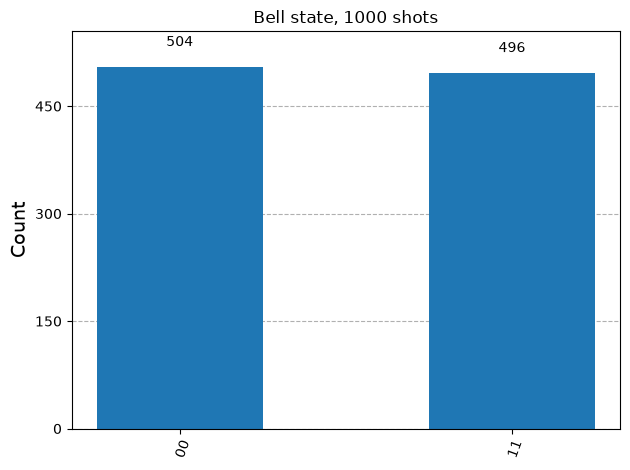

In [30]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

psi_bell = Statevector(bell)
print(psi_bell)
print(psi_bell.probabilities_dict())

bell_meas = bell.copy()
bell_meas.measure_all()
bell_counts = counts_of(bell_meas)
print(bell_counts)

# Checkpoint: amplitudes 1/sqrt(2) on |00> and |11>, zero elsewhere; only 00 and 11 in the counts
assert np.allclose(psi_bell.data, bell_vec)
assert set(bell_counts) <= {"00", "11"}
assert abs(bell_counts.get("00", 0) / SHOTS - 0.5) < 0.06
plot_histogram(bell_counts, title="Bell state, 1000 shots")

There are four Bell states, one for each choice of relative sign and of which pairs are correlated:

| name | state | from $\lvert\Phi^+\rangle$ |
|---|---|---|
| $\lvert\Phi^+\rangle$ | $(\lvert 00\rangle + \lvert 11\rangle)/\sqrt2$ | |
| $\lvert\Phi^-\rangle$ | $(\lvert 00\rangle - \lvert 11\rangle)/\sqrt2$ | $Z$ on either qubit |
| $\lvert\Psi^+\rangle$ | $(\lvert 01\rangle + \lvert 10\rangle)/\sqrt2$ | $X$ on either qubit |
| $\lvert\Psi^-\rangle$ | $(\lvert 01\rangle - \lvert 10\rangle)/\sqrt2$ | $Z$ then $X$ |

### Your turn: two more Bell states

Build `qc_phi_minus` and `qc_psi_plus` from $|00\rangle$.

In [31]:
qc_phi_minus = QuantumCircuit(2)
qc_psi_plus = QuantumCircuit(2)

### WRITE YOUR CODE BELOW HERE ###
qc_phi_minus.h(0); qc_phi_minus.cx(0, 1); qc_phi_minus.z(0)
qc_psi_plus.h(0);  qc_psi_plus.cx(0, 1);  qc_psi_plus.x(0)

### YOUR CODE FINISHES HERE ###

In [32]:
# Checkpoint
phi_minus = Statevector(np.array([1, 0, 0, -1]) / np.sqrt(2))
psi_plus = Statevector(np.array([0, 1, 1, 0]) / np.sqrt(2))
assert qc_phi_minus.size() > 0 and qc_psi_plus.size() > 0, "fill in the cell above"
assert Statevector(qc_phi_minus).equiv(phi_minus), Statevector(qc_phi_minus).data
assert Statevector(qc_psi_plus).equiv(psi_plus), Statevector(qc_psi_plus).data
print("Phi-:", Statevector(qc_phi_minus).data, "   Psi+:", Statevector(qc_psi_plus).data)

Phi-: [ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]    Psi+: [0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]


## 11. Correlations in more than one basis

Measuring both qubits of $|\Phi^+\rangle$ in the $Z$ basis always gives equal bits. That alone is not remarkable: two coins glued heads-to-heads do the same. The difference shows up when both qubits are read in the $X$ basis (an $H$ on each before measuring). Rewriting the state in the $|\pm\rangle$ basis gives $|\Phi^+\rangle = (|{+}{+}\rangle + |{-}{-}\rangle)/\sqrt2$, so the bits agree there too.

In expectation values: $\langle ZZ\rangle$ is $+1$ when the two $Z$ outcomes agree and $-1$ when they differ, averaged. For $|\Phi^+\rangle$, $\langle ZZ\rangle = \langle XX\rangle = 1$. A product state can score 1 on one of these but never on both: $|{+}{+}\rangle$ has $\langle XX\rangle = 1$ and $\langle ZZ\rangle = 0$.

In [33]:
def measure_both(prep, basis):
    qc = prep.copy()
    if basis == "X":
        qc.h(0); qc.h(1)
    qc.measure_all()
    return counts_of(qc)

plus_plus = QuantumCircuit(2)
plus_plus.h(0); plus_plus.h(1)

results = {}
for name, prep in [("Bell", bell), ("|+>|+>", plus_plus)]:
    for basis in "ZX":
        results[(name, basis)] = measure_both(prep, basis)
        print(f"{name:<7} {basis}{basis} basis: {results[(name, basis)]}")
    print(f"{name:<7} <ZZ> = {expectation(prep, 'ZZ'):+.3f}   <XX> = {expectation(prep, 'XX'):+.3f}   <ZX> = {expectation(prep, 'ZX'):+.3f}")

# Checkpoint
assert set(results[("Bell", "Z")]) <= {"00", "11"} and set(results[("Bell", "X")]) <= {"00", "11"}
assert np.isclose(expectation(bell, "ZZ"), 1) and np.isclose(expectation(bell, "XX"), 1)
assert np.isclose(expectation(plus_plus, "ZZ"), 0, atol=1e-9) and np.isclose(expectation(plus_plus, "XX"), 1)

Bell    ZZ basis: {'11': 507, '00': 493}
Bell    XX basis: {'00': 493, '11': 507}
Bell    <ZZ> = +1.000   <XX> = +1.000   <ZX> = +0.000
|+>|+>  ZZ basis: {'00': 226, '01': 264, '10': 257, '11': 253}
|+>|+>  XX basis: {'00': 1000}
|+>|+>  <ZZ> = +0.000   <XX> = +1.000   <ZX> = +0.000


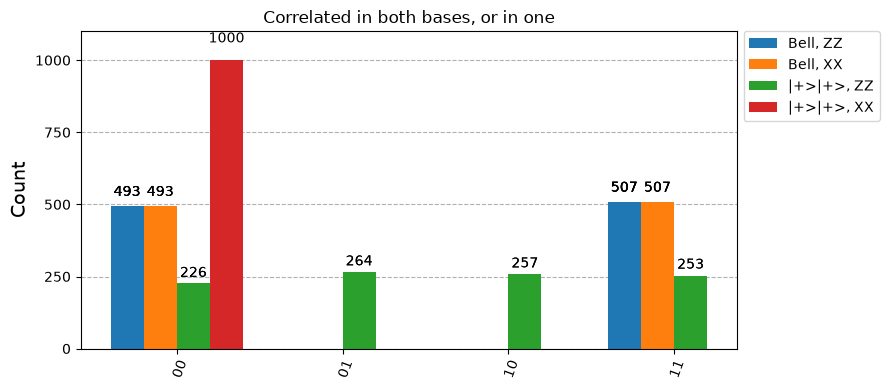

In [34]:
plot_histogram([results[("Bell", "Z")], results[("Bell", "X")], results[("|+>|+>", "Z")], results[("|+>|+>", "X")]],
               legend=["Bell, ZZ", "Bell, XX", "|+>|+>, ZZ", "|+>|+>, XX"], figsize=(9, 4),
               title="Correlated in both bases, or in one")

### Your turn: the $Y$ basis

Read both qubits of the Bell state in the $Y$ basis (`sdg` then `h` on each qubit before measuring, as in section 5.3) and store the counts in `counts_yy`. Predict first: in the $|{\pm}i\rangle$ basis, $|\Phi^+\rangle = (|{+}i,{-}i\rangle + |{-}i,{+}i\rangle)/\sqrt2$, so the two bits should now always **differ**.

In [35]:
counts_yy = None

### WRITE YOUR CODE BELOW HERE ###
qc_yy = bell.copy()
for q in (0, 1):
    qc_yy.sdg(q)
    qc_yy.h(q)
qc_yy.measure_all()
counts_yy = counts_of(qc_yy)

### YOUR CODE FINISHES HERE ###

In [36]:
# Checkpoint: only 01 and 10 appear, and <YY> = -1
assert counts_yy is not None, "fill in the cell above"
assert set(counts_yy) <= {"01", "10"}, counts_yy
assert np.isclose(expectation(bell, "YY"), -1)
print(counts_yy, "   <YY> =", expectation(bell, "YY"))

{'01': 516, '10': 484}    <YY> = -0.9999999999999998


## 12. GHZ states and the cost of simulating $n$ qubits

The Bell construction extends to any number of qubits: one $H$, then a chain of CNOTs, gives the **GHZ state** $(|0\cdots0\rangle + |1\cdots1\rangle)/\sqrt2$.

### Your turn: GHZ on $n$ qubits

Complete `ghz(n)` so that it returns the circuit: `h` on qubit 0, then `cx(q, q + 1)` for each neighbouring pair.

In [37]:
def ghz(n):
    qc = None

    ### WRITE YOUR CODE BELOW HERE ###
    qc = QuantumCircuit(n)
    qc.h(0)
    for q in range(n - 1):
        qc.cx(q, q + 1)
        
    ### YOUR CODE FINISHES HERE ###
    return qc

In [38]:
# Checkpoint
qc5 = ghz(5)
assert qc5 is not None, "ghz returns None: fill in the cell above"
sv5 = Statevector(qc5)
assert np.isclose(abs(sv5.data[0]) ** 2, 0.5) and np.isclose(abs(sv5.data[-1]) ** 2, 0.5)
qc5m = qc5.copy(); qc5m.measure_all()
c5 = counts_of(qc5m)
assert set(c5) <= {"00000", "11111"}, c5
print(c5)

{'11111': 492, '00000': 508}


A state vector of $n$ qubits holds $2^n$ complex numbers, 16 bytes each, so every extra qubit doubles the memory and roughly doubles the time. Around 30 qubits a laptop runs out of memory; around 49, so does the largest supercomputer; at 56 the vector is an exabyte. Day 9 is about what to do then.

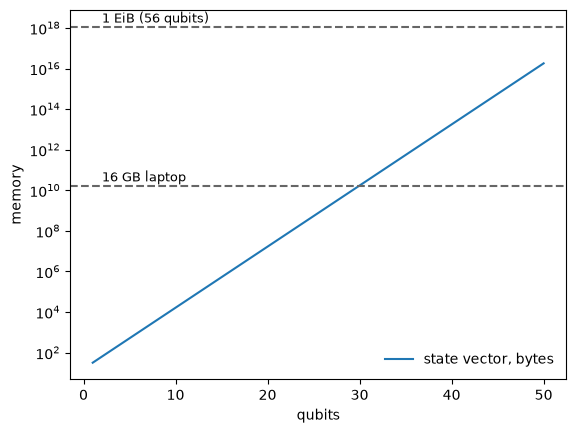

In [39]:
n_axis = np.arange(1, 51)
plt.semilogy(n_axis, 2.0 ** n_axis * 16, label="state vector, bytes")
plt.axhline(16 * 2 ** 30, ls="--", color="0.4"); plt.text(2, 16 * 2 ** 30 * 1.6, "16 GB laptop", fontsize=9)
plt.axhline(2 ** 60, ls="--", color="0.4"); plt.text(2, 2 ** 60 * 1.6, "1 EiB (56 qubits)", fontsize=9)
plt.xlabel("qubits"); plt.ylabel("memory"); plt.legend(frameon=False)
plt.show()

## 13. The Bell state on a real processor (optional)

The Bell circuit of section 10 is the standard first test of a two-qubit gate on a real chip. Two things change in the code, as on Day 1: the circuit goes through a pass manager for the chosen backend, here at optimization level 3 so that the layout pass picks a well-calibrated coupled pair rather than the first two qubits, and it is submitted through a Sampler. About 2 seconds of QPU time. Runs only if `RUN_ON_HARDWARE = True` in section 1 and an IBM account is saved; otherwise the cell after uses the counts cached from a recorded run.

In [40]:
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

job = None
if RUN_ON_HARDWARE and service is not None:
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=2)
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    bell_isa = pm.run(bell_meas)
    print(f"Using {backend.name}; the Bell pair sits on physical qubits {sorted(bell_isa.layout.final_index_layout())}")
    print("Gates the chip will run:", dict(bell_isa.count_ops()))
    job = Sampler(mode=backend).run([bell_isa], shots=SHOTS)
    print("Job id:", job.job_id(), " status:", job.status())
else:
    print("RUN_ON_HARDWARE is False or no account saved: using the cached hardware result below.")

Using ibm_kingston; the Bell pair sits on physical qubits [55, 59]
Gates the chip will run: {'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1}
Job id: dal16o6lg97s73c8dh90  status: QUEUED


Using your result from ibm_kingston
exact (Born rule)  {'00': 500, '11': 500}
simulator          {'00': 504, '11': 496}
hardware           {'00': 512, '11': 478, '01': 6, '10': 4}
impossible outcomes 01 and 10 on hardware: 1.0%


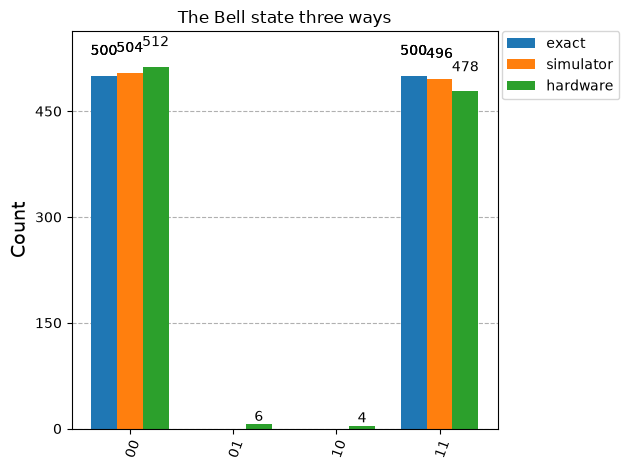

In [42]:
CACHED_QPU_COUNTS = {"00": 512, "11": 478, "01": 6, "10": 4}     # recorded on ibm_kingston (Heron r2), physical qubits 55 and 59, 1000 shots

def qpu_counts_or_cached(job):
    if job is None:
        return CACHED_QPU_COUNTS
    try:
        if job.status() == "DONE":
            print(f"Using your result from {job.backend().name}")
            return job.result()[0].data.meas.get_counts()
        print(f"Job is {job.status()}; using the cached result for now. Re-run this cell later.")
    except Exception as e:
        print("Could not fetch the job:", e)
    return CACHED_QPU_COUNTS

qpu_counts = qpu_counts_or_cached(job)
exact_counts = {str(k): int(round(p * SHOTS)) for k, p in psi_bell.probabilities_dict().items()}   # the Born rule, as counts

if qpu_counts is None:
    print("No recorded hardware run yet: run the cell above with RUN_ON_HARDWARE = True.")
else:
    impossible = (qpu_counts.get("01", 0) + qpu_counts.get("10", 0)) / sum(qpu_counts.values())
    for name, c in [("exact (Born rule)", exact_counts), ("simulator", bell_counts), ("hardware", qpu_counts)]:
        print(f"{name:<18} {c}")
    print(f"impossible outcomes 01 and 10 on hardware: {impossible:.1%}")
    display(plot_histogram([exact_counts, bell_counts, qpu_counts], legend=["exact", "simulator", "hardware"],
                           title="The Bell state three ways"))

The exact counts are the Born rule of section 5 turned into numbers, the simulator draws from them, and the processor adds what the mathematics does not have: some `01` and `10`, outcomes the ideal circuit can never produce, and an imbalance between `00` and `11`. They come from the two-qubit gate, from the qubits decaying during the circuit, and from readout error. Day 5 measures each of the three separately and shows how much of this can be corrected.

## 14. Summary

- The Paulis $X$, $Y$, $Z$ square to the identity, anticommute pairwise, and are half-turns about their own Bloch axis. Rotations $R_x, R_y, R_z(\theta)$ turn by any angle; $R_y(\theta)|0\rangle$ has $P(1) = \sin^2(\theta/2)$, and every one-qubit gate is $U(\theta,\phi,\lambda)$.
- A circuit's matrix is the product of its gates in reverse order; gates do not commute; `inverse()` undoes a circuit.
- Measurement collapses the state. Rotating before measuring reads another basis: $H$ for $X$, $S^\dagger H$ for $Y$. $\langle Z\rangle = P(0) - P(1)$ is a Bloch coordinate; the Sampler returns counts and the Estimator returns expectation values.
- Two qubits are a length-4 vector; a product state is a tensor product. Qiskit labels bitstrings with qubit 0 on the right.
- A state is entangled when its $2\times2$ amplitude matrix has rank two; then neither qubit has a state of its own.
- CNOT is Day 1's reversible XOR and its own inverse; CZ flips the sign of $|11\rangle$; SWAP exchanges qubits; any gate can be controlled.
- $H$ then CNOT makes the Bell state; its bits agree in the $Z$ and $X$ bases and disagree in the $Y$ basis, which no product state does.
- GHZ generalizes Bell to $n$ qubits, and a state vector costs $2^n \times 16$ bytes.
- On a real processor the Bell state comes back with a few percent of `01` and `10`, outcomes the ideal circuit cannot produce; Day 5 measures where they come from.

## Further reading

- [Basics of Quantum Information, lessons 1 and 2](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/introduction), John Watrous
- [Circuit library](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library) in the Qiskit API reference, for every gate's matrix
- [Primitives](https://quantum.cloud.ibm.com/docs/en/guides/primitives): Sampler and Estimator
- [Bit ordering in Qiskit](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering)
- M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, sections 1.3.5 to 1.3.7, 2.2.8, and 4.2